<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Analysis</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Import Libraries</h3>
</div>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from copy import copy

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.special import erf
from pathlib import Path

from datetime import datetime
import json

#import ipywidgets as widgets
from IPython.display import display

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Load Data</h3>
</div>

In [8]:
base_dir = Path(r"C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts")
run_numbers = range(198, 200)  # 150-158 inclusive

runs = {}
for run_num in run_numbers:
    matches = list(base_dir.glob(f"*_{run_num}"))
    if not matches:
        print(f"no folder found for run {run_num}")
        continue
    folder = matches[0]

    npz_path = folder / "data.npz"
    data = np.load(npz_path)

    metadata_path = folder / "metadata.json"
    with open(metadata_path) as f:
        metadata = json.load(f)

    runs[run_num] = {
        "data": data,
        "metadata": metadata,
        "folder": folder,
    }
    print(f"loaded run {run_num}: {folder.name}")

loaded run 198: 20260714181147_198
loaded run 199: 20260714185251_199


In [9]:
spd_run_numbers = range(198, 200)  # 198-199 inclusive

spd_runs = {}
for run_num in spd_run_numbers:
    matches = list(base_dir.glob(f"*_{run_num}"))
    if not matches:
        print(f"no folder found for run {run_num}")
        continue
    folder = matches[0]

    npz_path = folder / "data.npz"
    data = np.load(npz_path)

    metadata_path = folder / "metadata.json"
    with open(metadata_path) as f:
        metadata = json.load(f)

    spd_runs[run_num] = {
        "data": data,
        "metadata": metadata,
        "folder": folder,
    }
    print(f"loaded run {run_num}: {folder.name}")

loaded run 198: 20260714181147_198
loaded run 199: 20260714185251_199


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Analyze</h3>
</div>

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Available Data</h4>
</div>

In [12]:
run_num = list(runs.keys())[0]
t = runs[run_num]["data"]["delays_ns"]
y = runs[run_num]["data"]["signal_mean"]
gate_width = runs[run_num]["metadata"]["gate_width_tns"]

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Plot Raw Data</h4>
</div>

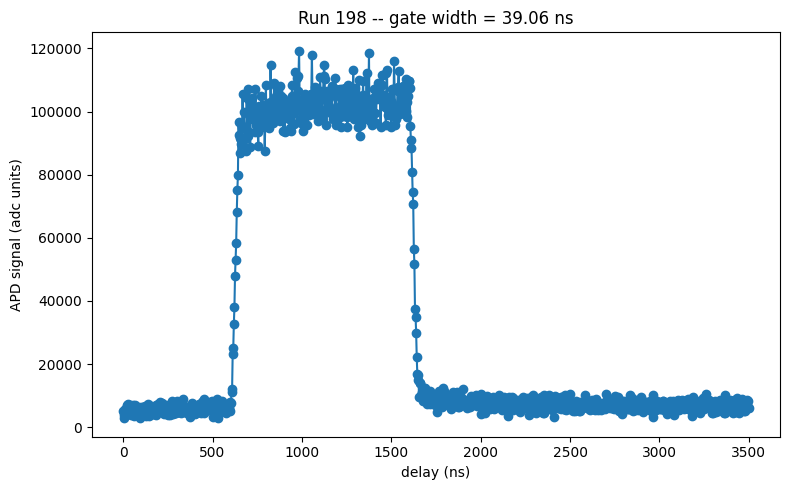

In [11]:
run_num = 198
t = spd_runs[run_num]["data"]["delays_ns"]
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
gate_width = spd_runs[run_num]["metadata"]["gate_width_tns"]

gate_width_s = gate_width * 1e-9
y = counts_mean / gate_width_s   # now genuinely cps, matching the original plot

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, y, 'o-')
ax.set_xlabel('delay (ns)')
ax.set_ylabel('APD signal (adc units)')
ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')
plt.tight_layout()
plt.show()

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Fit Function</h4>
</div>

In [12]:
def double_erf_step(t, baseline, amp1, t0_1, sigma1, amp2, t0_2, sigma2):
    fast = amp1 * 0.5 * (1 + erf((t - t0_1) / (sigma1 * np.sqrt(2))))
    slow = amp2 * 0.5 * (1 + erf((t - t0_2) / (sigma2 * np.sqrt(2))))
    return baseline + fast + slow

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Plot Fit</h4>
</div>

SPD

In [97]:
spd_run_numbers = range(219, 220)  # 168-176 inclusive

spd_runs = {}
for run_num in spd_run_numbers:
    matches = list(base_dir.glob(f"*_{run_num}"))
    if not matches:
        print(f"no folder found for run {run_num}")
        continue
    folder = matches[0]

    npz_path = folder / "data.npz"
    data = np.load(npz_path)

    metadata_path = folder / "metadata.json"
    with open(metadata_path) as f:
        metadata = json.load(f)

    spd_runs[run_num] = {
        "data": data,
        "metadata": metadata,
        "folder": folder,
    }
    print(f"loaded run {run_num}: {folder.name}")

loaded run 219: 20260716162253_219


In [98]:
run_num = 219
t = spd_runs[run_num]["data"]["delays_ns"]
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
gate_width = spd_runs[run_num]["metadata"]["gate_width_tns"]

gate_width_s = gate_width * 1e-9
y = counts_mean / gate_width_s   # now genuinely cps, matching the original plot

baseline_guess = y[:10].mean()
total_rise = y[-10:].mean() - baseline_guess

p0 = [
    baseline_guess,
    total_rise * 0.7,
    655,
    10,
    total_rise * 0.3,
    750,
    80
]

popt, pcov = curve_fit(double_erf_step, t, y, p0=p0, maxfev=10000)
baseline, amp1, t0_1, sigma1, amp2, t0_2, sigma2 = popt

rise_time_fast = 2.563 * sigma1
rise_time_slow = 2.563 * sigma2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, y, 'o', alpha=0.5, label='data')
ax.plot(t, double_erf_step(t, *popt), '-', color='red', label='double erf fit')
ax.legend(loc='lower right')

fit_text = (
    f"baseline = {baseline:.0f}\n"
    f"fast: t0={t0_1:.1f} ns, rise={rise_time_fast:.1f} ns, amp={amp1:.0f}\n"
    f"slow: t0={t0_2:.1f} ns, rise={rise_time_slow:.1f} ns, amp={amp2:.0f}"
)

ax.text(0.98, 0.35, fit_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('delay (ns)')
ax.set_ylabel('count rate (cps)')
ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Noise Analysis</h5>
</div>

In [76]:
def find_settled_regions(t, y, buffer_ns_rise=60, buffer_ns_fall=400, smooth_window_ns=20):
    t = np.asarray(t)
    y = np.asarray(y)
    dt = np.median(np.diff(t))
    smooth_pts = max(1, int(round(smooth_window_ns / dt)))

    kernel = np.ones(smooth_pts) / smooth_pts
    y_smooth = np.convolve(y, kernel, mode='same')

    thresh = (y_smooth.max() + y_smooth.min()) / 2
    above = y_smooth > thresh
    high_idxs = np.where(above)[0]
    rise_idx = high_idxs[0]
    fall_idx = high_idxs[-1]

    buffer_pts_rise = int(round(buffer_ns_rise / dt))
    buffer_pts_fall = int(round(buffer_ns_fall / dt))

    plateau_start = rise_idx + buffer_pts_rise
    plateau_end = fall_idx - buffer_pts_rise  # still using rise-side buffer for the plateau's own leading edge into the fall

    plateau_mask = np.zeros_like(t, dtype=bool)
    plateau_mask[plateau_start:plateau_end] = True

    baseline_mask = np.zeros_like(t, dtype=bool)
    baseline_mask[:rise_idx - buffer_pts_rise] = True
    baseline_mask[fall_idx + buffer_pts_fall:] = True  # bigger buffer here to clear the decay tail

    excluded_mask = ~(plateau_mask | baseline_mask)
    return baseline_mask, plateau_mask, excluded_mask


Plot to Find Baseline Markers and Peak Markers

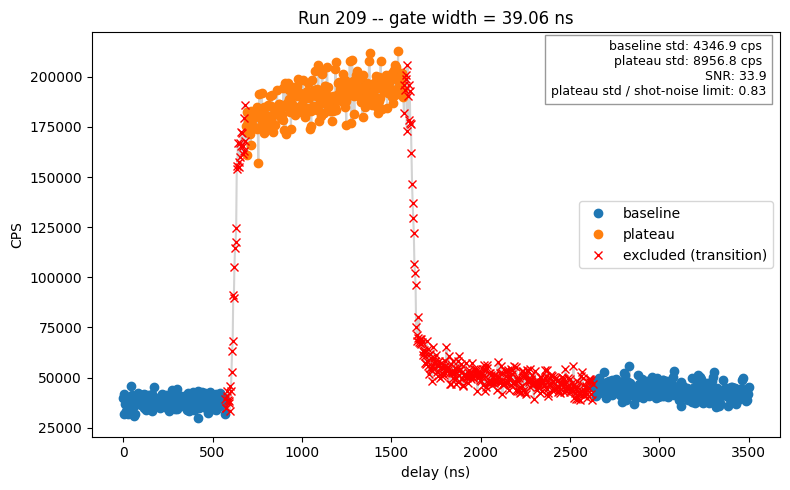

baseline std: 4346.9 cps  plateau std: 8956.8 cps
plateau std / shot-noise limit: 0.83  (1.0 = shot-noise-limited)


In [96]:
baseline_mask, plateau_mask, excluded_mask = find_settled_regions(t, y, buffer_ns_rise=60, buffer_ns_fall=1000, smooth_window_ns=20)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, y, '-', color='lightgray', zorder=1)
ax.plot(t[baseline_mask], y[baseline_mask], 'o', color='tab:blue', label='baseline')
ax.plot(t[plateau_mask], y[plateau_mask], 'o', color='tab:orange', label='plateau')
ax.plot(t[excluded_mask], y[excluded_mask], 'x', color='red', label='excluded (transition)')
ax.legend()
ax.set_xlabel('delay (ns)')
ax.set_ylabel('CPS')
ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')

baseline_mean = y[baseline_mask].mean()
plateau_mean = y[plateau_mask].mean()
baseline_std = y[baseline_mask].std()
plateau_std = y[plateau_mask].std()



snr = (plateau_mean - baseline_mean) / baseline_std

# shot-noise check -- needs raw counts, not cps, since Poisson stats apply to counts
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
plateau_counts_mean = counts_mean[plateau_mask].mean()
shot_noise_limit = np.sqrt(plateau_counts_mean)  # expected std in counts if shot-noise-limited
reps = spd_runs[run_num]["metadata"]["reps"]  
shot_noise_limit = np.sqrt(plateau_counts_mean / reps)
excess_noise_ratio = plateau_std_counts / shot_noise_limit

stats_text = (f"baseline std: {baseline_std:.1f} cps \n"
              f"plateau std: {plateau_std:.1f} cps \n"
              f"SNR: {snr:.1f}\n"
              f"plateau std / shot-noise limit: {excess_noise_ratio:.2f}")
ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"baseline std: {baseline_std:.1f} cps  plateau std: {plateau_std:.1f} cps")
print(f"plateau std / shot-noise limit: {excess_noise_ratio:.2f}  (1.0 = shot-noise-limited)")



In [79]:
print(reps)

100000


Save

In [78]:
save_dir = base_dir / "convolution_fits_spd" / "SNR"
save_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(save_dir / f"run{run_num}_gatewidth{gate_width:.2f}ns_SNR.png", dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Loop and Save</h4>
</div>

SPD

In [31]:
fit_dir_spd = base_dir / "convolution_fits_spd"
fit_dir_spd.mkdir(exist_ok=True)

fit_results_spd = {}

for run_num in spd_runs:
    t = spd_runs[run_num]["data"]["delays_ns"]
    counts_mean = spd_runs[run_num]["data"]["counts_mean"]
    gate_width = spd_runs[run_num]["metadata"]["gate_width_tns"]

    gate_width_s = gate_width * 1e-9
    y = counts_mean / gate_width_s

    baseline_guess = y[:10].mean()
    total_rise = y[-10:].mean() - baseline_guess

    p0 = [
        baseline_guess,
        total_rise * 0.7,
        655,
        10,
        total_rise * 0.3,
        750,
        80
    ]

    try:
        popt, pcov = curve_fit(double_erf_step, t, y, p0=p0, maxfev=10000)
    except RuntimeError as e:
        print(f"Run {run_num}: fit failed -- {e}")
        continue

    baseline, amp1, t0_1, sigma1, amp2, t0_2, sigma2 = popt
    rise_time_fast = 2.563 * sigma1
    rise_time_slow = 2.563 * sigma2

    fit_results_spd[run_num] = {
        "gate_width_tns": gate_width,
        "baseline": baseline,
        "rise_time_fast_ns": rise_time_fast,
        "rise_time_slow_ns": rise_time_slow,
        "amp1": amp1,
        "amp2": amp2,
        "t0_1": t0_1,
        "t0_2": t0_2,
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t, y, 'o', alpha=0.5, label='data')
    ax.plot(t, double_erf_step(t, *popt), '-', color='red', label='double erf fit')
    ax.legend(loc='lower right')

    fit_text = (
        f"baseline = {baseline:.0f}\n"
        f"fast: t0={t0_1:.1f} ns, rise={rise_time_fast:.1f} ns, amp={amp1:.0f}\n"
        f"slow: t0={t0_2:.1f} ns, rise={rise_time_slow:.1f} ns, amp={amp2:.0f}"
    )

    ax.text(0.98, 0.35, fit_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('delay (ns)')
    ax.set_ylabel('count rate (cps)')
    ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')
    plt.tight_layout()
    fig.savefig(fit_dir_spd / f"run{run_num}_fit.png", dpi=150)
    plt.close(fig)

    print(f"Run {run_num}: gate={gate_width:.1f}ns, fast_rise={rise_time_fast:.1f}ns, slow_rise={rise_time_slow:.1f}ns")

print(f"\nSaved {len(fit_results_spd)} fit plots to {fit_dir_spd}")

Run 181: gate=45.6ns, fast_rise=55.5ns, slow_rise=20.5ns


C:\Users\hlab_\AppData\Local\Temp\ipykernel_25200\809390307.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(double_erf_step, t, y, p0=p0, maxfev=10000)


Run 182: gate=48.8ns, fast_rise=45.1ns, slow_rise=87.0ns
Run 183: gate=55.3ns, fast_rise=82.1ns, slow_rise=25.5ns
Run 184: gate=58.6ns, fast_rise=86.6ns, slow_rise=27.7ns
Run 185: gate=65.1ns, fast_rise=86.8ns, slow_rise=24.4ns
Run 186: gate=71.6ns, fast_rise=85.9ns, slow_rise=25.4ns
Run 187: gate=74.9ns, fast_rise=85.0ns, slow_rise=28.2ns
Run 188: gate=81.4ns, fast_rise=54.0ns, slow_rise=79.9ns

Saved 8 fit plots to C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts\convolution_fits_spd
